In [ ]:
%pip install -q opencv-python

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Image loaded successfully. Shape: (396, 599)


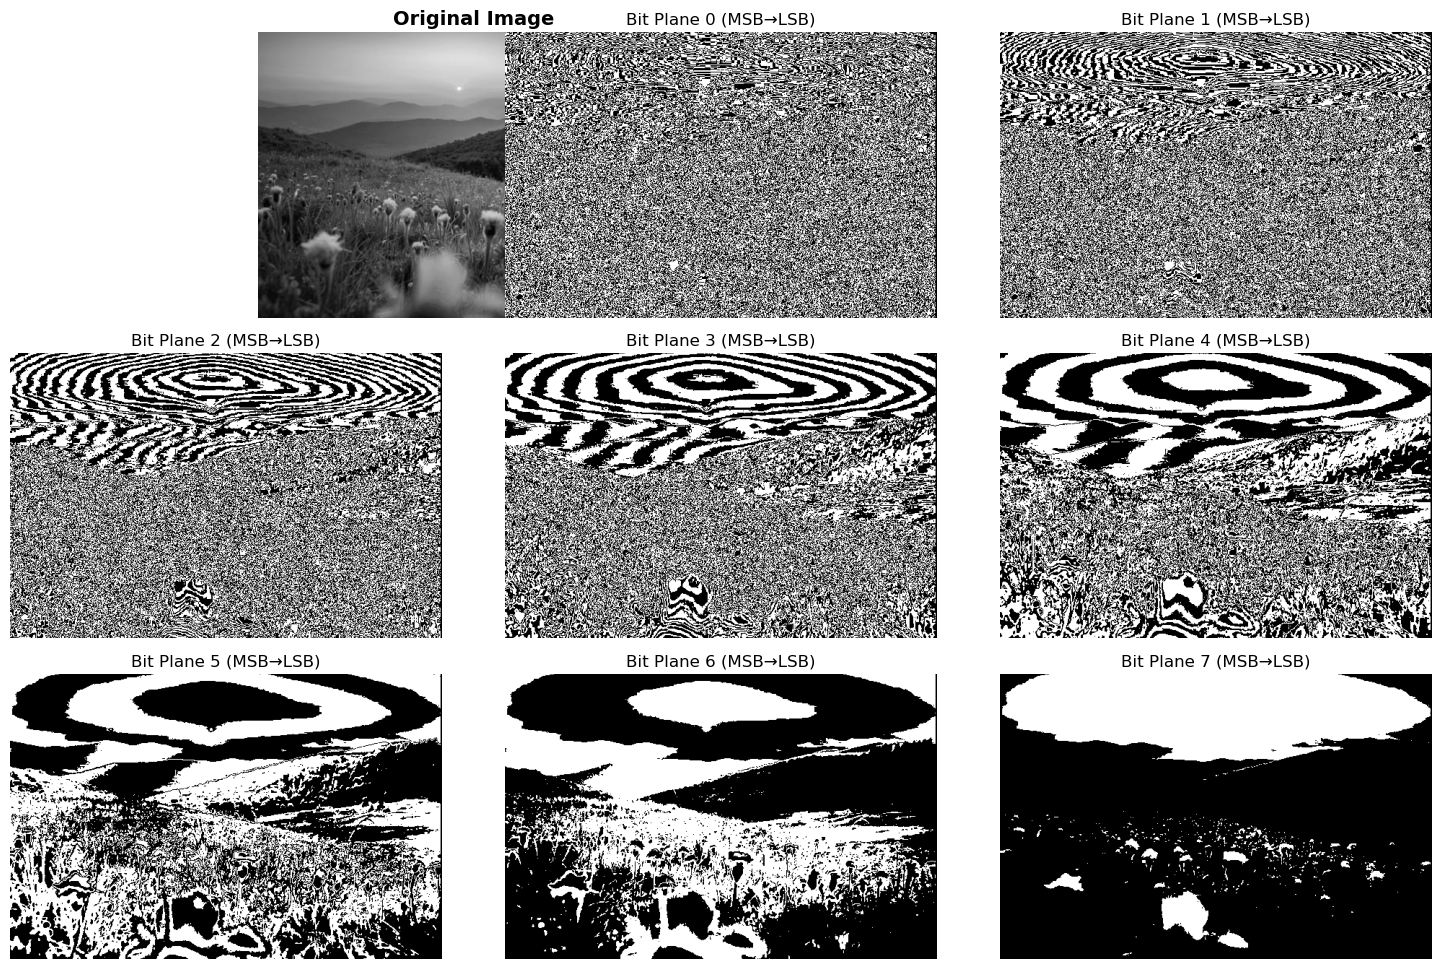


Bit Plane Slicing Complete!
Original image shape: (396, 599)
Number of bit planes extracted: 8
Each bit plane shape: (396, 599)


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image
import os

# Try to load image with PIL, otherwise create sample
try:
    if os.path.exists('image.jpg'):
        image = np.array(Image.open('image.jpg').convert('L'))
        print(f"Image loaded successfully. Shape: {image.shape}")
    else:
        # Create sample image
        image = np.random.randint(0, 256, (256, 256), dtype=np.uint8)
        print("Created a random sample image")
except Exception as e:
    print(f"Could not load image: {e}")
    image = np.random.randint(0, 256, (256, 256), dtype=np.uint8)
    print("Using random sample image")

# Function to extract bit planes
def get_bit_planes(image):
    """
    Extract all 8 bit planes from a grayscale image.
    Each bit plane represents one bit position (0-7) across all pixels.
    """
    bit_planes = []
    for i in range(8):
        # Extract the i-th bit plane
        bit_plane = (image >> i) & 1
        # Scale to 0-255 for visualization
        bit_plane = bit_plane * 255
        bit_planes.append(bit_plane.astype(np.uint8))
    return bit_planes

# Extract all bit planes
bit_planes = get_bit_planes(image)

# Display original image and all bit planes
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(3, 3, figure=fig)

# Original image
ax0 = fig.add_subplot(gs[0, :2])
ax0.imshow(image, cmap='gray')
ax0.set_title('Original Image', fontsize=14, fontweight='bold')
ax0.axis('off')

# Display all 8 bit planes
for i in range(8):
    row = (i + 1) // 3
    col = (i + 1) % 3
    ax = fig.add_subplot(gs[row, col])
    ax.imshow(bit_planes[i], cmap='gray')
    ax.set_title(f'Bit Plane {i} (MSB→LSB)', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('bit_planes_output.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBit Plane Slicing Complete!")
print(f"Original image shape: {image.shape}")
print(f"Number of bit planes extracted: {len(bit_planes)}")
print(f"Each bit plane shape: {bit_planes[0].shape}")